# Public Wolffia Trusted Marker-Panel Scoring

## tl;dr

This notebook scores the four public Waus8730 Wolffia runs using the smaller first-pass trusted native marker panel. The panel is derived from the broader candidate marker table but keeps only high-confidence, review-ready markers plus a separate unknown-marker watchlist.

Executed result summary:

- 60 marker-program rows were retained in the first-pass trusted panel.
- The panel contains 46 core markers, 9 supporting markers, and 5 unknown-marker watchlist entries.
- All trusted-panel genes were present in the Waus8730 matrix.
- 11,084 public Wolffia cells were scored across four runs.
- Dawn-group cells remained higher for photosynthesis/light harvesting, carbon fixation/assimilation, and chloroplast gene expression/plastid translation.
- Dusk-group cells remained higher for nutrient transport, RNA-binding/regulatory, and stress/chaperone response.

This is still a provisional scoring layer. It is meant to make future manual review and salt-stress comparison easier, not to finalize Wolffia cell-type annotation.

## Context & Methods

The previous notebook scored cells with all Wolffia-native marker candidates. This notebook repeats the same idea using a smaller panel:

- `core_marker`: high-evidence marker with top-five rank in at least one native Wolffia cluster.
- `supporting_marker`: high- or medium-evidence marker within the top-eight ranks.
- `watchlist_unknown`: strong unknown markers kept for tracking, but not treated as final biology.

Program scores are calculated as mean normalized/log1p expression over marker genes in each program.

### Key assumptions

- Scores are program activity summaries, not hard labels.
- The trusted panel is a first-pass computational panel and still needs manual biological review.
- Large `.h5ad` inputs stay on external project storage; only summaries and the notebook are stored in the repository.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
sc.settings.verbosity = 2

# nbconvert may execute from the notebooks/ folder. Walk upward until the repo marker is found.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name == "notebooks" or not (REPO_ROOT / "data" / "metadata").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repository root")
    REPO_ROOT = REPO_ROOT.parent

SSD_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")
PROCESSED_DIR = SSD_ROOT / "results" / "processed_h5ad"
MODEL_DIR = SSD_ROOT / "results" / "model_application"

PANEL_TABLE = REPO_ROOT / "data" / "metadata" / "wolffia_trusted_native_marker_panel.csv"
OUT_META = REPO_ROOT / "data" / "metadata"
OUT_FIG = REPO_ROOT / "figures" / "wolffia_trusted_marker_panel_scores"
OUT_META.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "SRR29417746": {"timepoint": "dawn", "replicate": "dawn_1"},
    "SRR29417745": {"timepoint": "dawn", "replicate": "dawn_2"},
    "SRR29417744": {"timepoint": "dusk", "replicate": "dusk_1"},
    "SRR29417743": {"timepoint": "dusk", "replicate": "dusk_2"},
}
RUNS = list(RUN_METADATA)

print("Repository:", REPO_ROOT)
print("External data root:", SSD_ROOT)
print("Trusted panel:", PANEL_TABLE)

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
External data root: /Volumes/LaCie/wolffia_single_cell
Trusted panel: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_trusted_native_marker_panel.csv


## Data

Load the trusted marker panel and the four public normalized Waus8730 matrices.

In [2]:
trusted_panel = pd.read_csv(PANEL_TABLE)
print("Trusted panel rows:", len(trusted_panel))
print("Unique marker-program pairs:", trusted_panel[["native_program_id", "waus8730_gene_id"]].drop_duplicates().shape[0])
trusted_panel.groupby(["native_program_name", "trusted_panel_tier"]).size().unstack(fill_value=0)

Trusted panel rows: 60
Unique marker-program pairs: 60


trusted_panel_tier,core_marker,supporting_marker,watchlist_unknown
native_program_name,,,
Carbon fixation / assimilation,8,0,0
Chloroplast gene expression / plastid translation,6,2,0
Ion / water balance,4,3,0
Lipid / surface / cell-wall biology,7,1,0
Nutrient transport,3,2,0
Photosynthesis / light harvesting,8,0,0
RNA-binding / regulatory,3,0,0
Stress / chaperone response,7,1,0
Unknown high-ranking marker,0,0,5


In [3]:
adatas = []
for run in RUNS:
    h5ad_path = PROCESSED_DIR / f"{run}_normalized_log1p.h5ad"
    pred_path = MODEL_DIR / run / "combined_leaf_root_predictions.csv"
    if not h5ad_path.exists():
        raise FileNotFoundError(h5ad_path)
    if not pred_path.exists():
        raise FileNotFoundError(pred_path)

    sample = ad.read_h5ad(h5ad_path)
    sample.obs_names = [f"{run}_{bc}" for bc in sample.obs_names.astype(str)]
    sample.obs["run"] = run
    sample.obs["timepoint"] = RUN_METADATA[run]["timepoint"]
    sample.obs["replicate"] = RUN_METADATA[run]["replicate"]

    predictions = pd.read_csv(pred_path)
    predictions.index = [f"{run}_{bc}" for bc in predictions["cell_id"].astype(str)]
    sample.obs = sample.obs.join(
        predictions[["final_label", "final_interpretation_status", "leaf_accepted", "root_accepted"]],
        how="left",
    )
    adatas.append(sample)

combined = ad.concat(adatas, join="inner", merge="same", label="run_from_concat", keys=RUNS)
combined.obs["final_label"] = combined.obs["final_label"].fillna("missing_prediction")
combined.obs["final_interpretation_status"] = combined.obs["final_interpretation_status"].fillna("missing_prediction")

print(combined)
print("Cells:", combined.n_obs)
print("Genes:", combined.n_vars)

AnnData object with n_obs × n_vars = 11084 × 15080
    obs: 'run', 'timepoint', 'replicate', 'final_label', 'final_interpretation_status', 'leaf_accepted', 'root_accepted', 'run_from_concat'
    var: 'feature_type'
Cells: 11084
Genes: 15080


## Score trusted native programs

For each program, compute the mean normalized/log1p expression of trusted marker genes that are present in the matrix. Core and supporting markers are both included. Unknown watchlist markers are scored separately under the unknown-marker program.

In [4]:
def mean_expression_score(adata, genes):
    present = [g for g in genes if g in adata.var_names]
    if not present:
        return np.full(adata.n_obs, np.nan), present
    X = adata[:, present].X
    if hasattr(X, "toarray"):
        values = np.asarray(X.mean(axis=1)).ravel()
    else:
        values = np.asarray(X).mean(axis=1)
    return values, present

program_name_lookup = trusted_panel.drop_duplicates("native_program_id").set_index("native_program_id")["native_program_name"].to_dict()
coverage_rows = []

for program_id, sub in trusted_panel.groupby("native_program_id"):
    genes = sorted(sub["waus8730_gene_id"].dropna().unique())
    scores, present = mean_expression_score(combined, genes)
    score_col = f"trusted_score_{program_id}"
    z_col = f"trusted_zscore_{program_id}"
    combined.obs[score_col] = scores
    combined.obs[z_col] = (scores - np.nanmean(scores)) / np.nanstd(scores) if np.nanstd(scores) > 0 else np.nan
    coverage_rows.append({
        "native_program_id": program_id,
        "native_program_name": program_name_lookup[program_id],
        "panel_genes": len(genes),
        "genes_present_in_matrix": len(present),
        "coverage_fraction": len(present) / len(genes),
        "core_markers": (sub["trusted_panel_tier"] == "core_marker").sum(),
        "supporting_markers": (sub["trusted_panel_tier"] == "supporting_marker").sum(),
        "watchlist_unknown_markers": (sub["trusted_panel_tier"] == "watchlist_unknown").sum(),
    })

trusted_coverage = pd.DataFrame(coverage_rows).sort_values("panel_genes", ascending=False)
coverage_path = OUT_META / "wolffia_trusted_native_program_score_gene_coverage.csv"
trusted_coverage.to_csv(coverage_path, index=False)
print("Wrote:", coverage_path)
trusted_coverage

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_trusted_native_program_score_gene_coverage.csv


,native_program_id,native_program_name,panel_genes,genes_present_in_matrix,coverage_fraction,core_markers,supporting_markers,watchlist_unknown_markers
0,carbon_fixation_assimilation,Carbon fixation / assimilation,8,8,1.0,8,0,0
1,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,8,8,1.0,6,2,0
3,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,8,8,1.0,7,1,0
5,photosynthesis_light_harvesting,Photosynthesis / light harvesting,8,8,1.0,8,0,0
7,stress_chaperone_response,Stress / chaperone response,8,8,1.0,7,1,0
2,ion_water_balance,Ion / water balance,7,7,1.0,4,3,0
4,nutrient_transport,Nutrient transport,5,5,1.0,3,2,0
8,unknown_high_marker,Unknown high-ranking marker,5,5,1.0,0,0,5
6,rna_binding_regulatory,RNA-binding / regulatory,3,3,1.0,3,0,0


## Compute UMAP for visualization

This combined UMAP is used to show where trusted marker-program scores localize in the public Wolffia expression landscape.

In [5]:
sc.pp.highly_variable_genes(combined, n_top_genes=3000, flavor="seurat")
sc.pp.pca(combined, n_comps=40, use_highly_variable=True, svd_solver="arpack")
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30)
sc.tl.umap(combined, random_state=11)
sc.tl.leiden(combined, resolution=0.8, key_added="leiden_trusted_panel", random_state=11)

print("Leiden clusters:", combined.obs["leiden_trusted_panel"].nunique())

extracting highly variable genes


    finished (0:00:00)


computing PCA


    with n_comps=40


    finished (0:00:01)


...

computing UMAP


    finished (0:00:04)


running Leiden clustering


    finished (0:00:01)


Leiden clusters: 15


## Results: trusted program summaries

The summary table compares trusted program scores by run, dawn/dusk group, transfer label, and native Leiden cluster.

In [6]:
score_cols = [c for c in combined.obs.columns if c.startswith("trusted_score_")]
summary_rows = []
for group_cols in [["run"], ["timepoint"], ["final_label"], ["leiden_trusted_panel"], ["timepoint", "final_label"]]:
    grouped = combined.obs.groupby(group_cols, observed=True)
    for group_key, group_df in grouped:
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        base = dict(zip(group_cols, group_key))
        for col in score_cols:
            program_id = col.replace("trusted_score_", "")
            summary_rows.append({
                "grouping": "+".join(group_cols),
                **base,
                "native_program_id": program_id,
                "native_program_name": program_name_lookup.get(program_id, program_id),
                "n_cells": len(group_df),
                "mean_score": group_df[col].mean(),
                "median_score": group_df[col].median(),
            })

trusted_score_summary = pd.DataFrame(summary_rows)
summary_path = OUT_META / "wolffia_trusted_native_program_score_summary.csv"
trusted_score_summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)
trusted_score_summary.head(12)

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/data/metadata/wolffia_trusted_native_program_score_summary.csv


,grouping,run,native_program_id,native_program_name,n_cells,mean_score,median_score,timepoint,final_label,leiden_trusted_panel
0,run,SRR29417743,carbon_fixation_assimilation,Carbon fixation / assimilation,2666,3.451801,3.548659,NaN,NaN,NaN
1,run,SRR29417743,chloroplast_gene_expression,Chloroplast gene expression / plastid translation,2666,1.895991,1.724616,NaN,NaN,NaN
2,run,SRR29417743,ion_water_balance,Ion / water balance,2666,1.408276,1.360490,NaN,NaN,NaN
3,run,SRR29417743,lipid_surface_cell_wall,Lipid / surface / cell-wall biology,2666,1.149879,1.088130,NaN,NaN,NaN
4,run,SRR29417743,nutrient_transport,Nutrient transport,2666,1.018700,0.681526,NaN,NaN,NaN
5,run,SRR29417743,photosynthesis_light_harvesting,Photosynthesis / light harvesting,2666,2.909780,2.943679,NaN,NaN,NaN
6,run,SRR29417743,rna_binding_regulatory,RNA-binding / regulatory,2666,2.987074,3.151434,NaN,NaN,NaN
7,run,SRR29417743,stress_chaperone_response,Stress / chaperone response,2666,1.323396,1.330437,NaN,NaN,NaN
8,run,SRR29417743,unknown_high_marker,Unknown high-ranking marker,2666,1.183049,1.146288,NaN,NaN,NaN
9,run,SRR29417744,carbon_fixation_assimilation,Carbon fixation / assimilation,2886,3.478190,3.571697,NaN,NaN,NaN


Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_trusted_marker_panel_scores/trusted_native_program_score_heatmaps.png


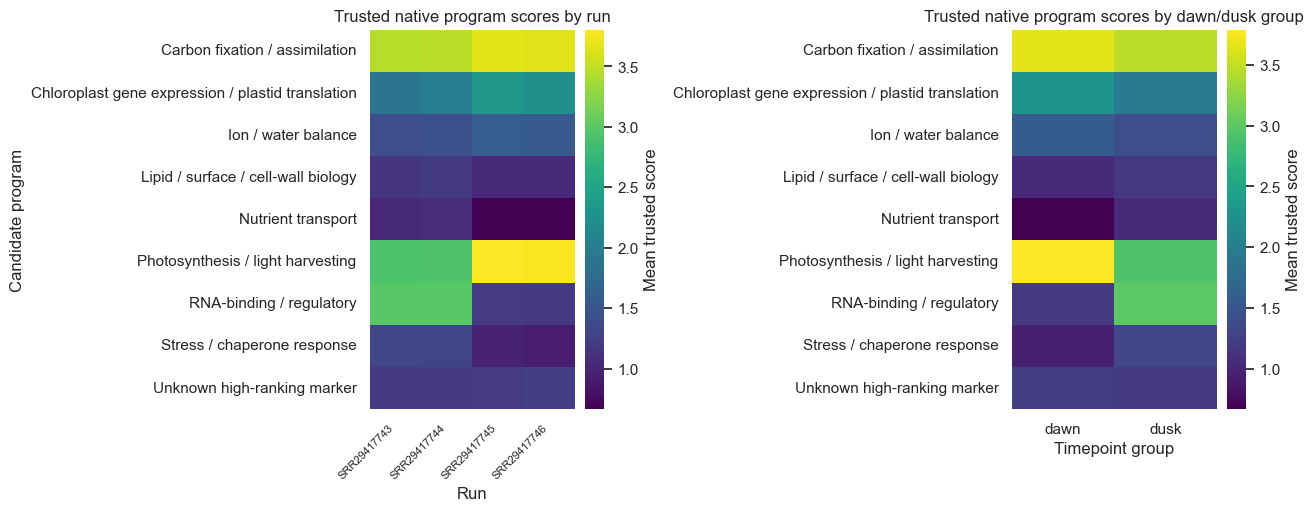

In [7]:
run_heatmap = (
    trusted_score_summary.query("grouping == 'run'")
    .pivot(index="native_program_name", columns="run", values="mean_score")
)
timepoint_heatmap = (
    trusted_score_summary.query("grouping == 'timepoint'")
    .pivot(index="native_program_name", columns="timepoint", values="mean_score")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.heatmap(run_heatmap, cmap="viridis", ax=axes[0], cbar_kws={"label": "Mean trusted score"})
axes[0].set_title("Trusted native program scores by run")
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Candidate program")
axes[0].tick_params(axis="x", labelrotation=45, labelsize=8)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

sns.heatmap(timepoint_heatmap, cmap="viridis", ax=axes[1], cbar_kws={"label": "Mean trusted score"})
axes[1].set_title("Trusted native program scores by dawn/dusk group")
axes[1].set_xlabel("Timepoint group")
axes[1].set_ylabel("")

fig_path = OUT_FIG / "trusted_native_program_score_heatmaps.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Results: UMAP overlays

These plots show whether trusted marker programs form localized regions in the combined Wolffia expression space.

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_trusted_marker_panel_scores/trusted_native_program_score_umap_grid.png


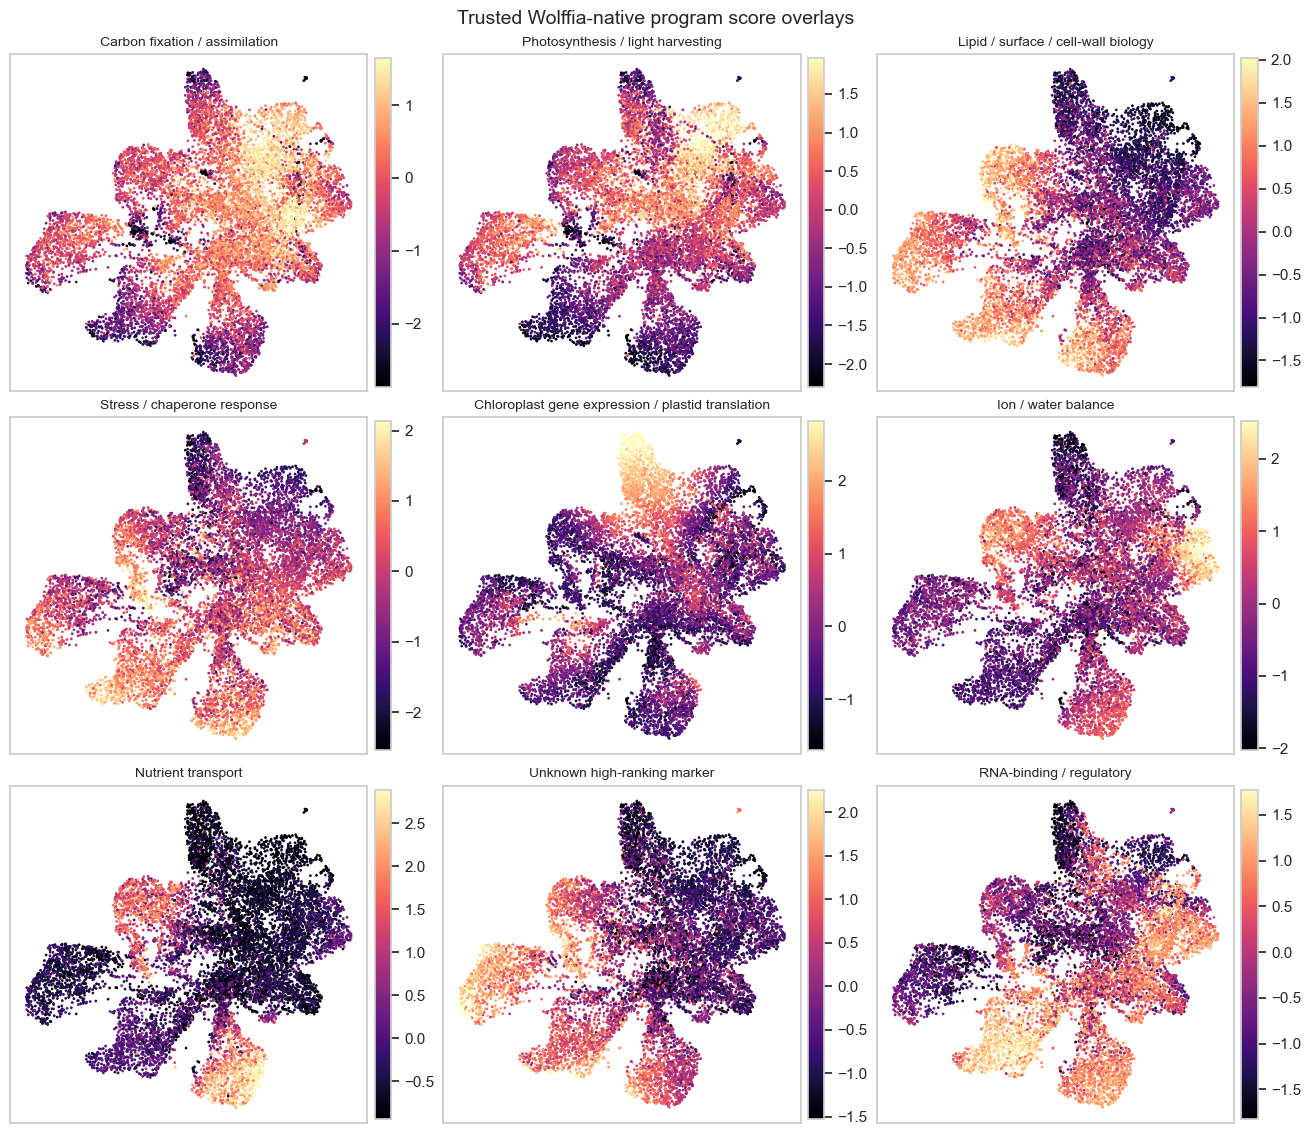

In [8]:
program_order = trusted_coverage.sort_values(["panel_genes", "core_markers"], ascending=False)["native_program_id"].tolist()
plot_cols = [f"trusted_zscore_{pid}" for pid in program_order]
plot_titles = [program_name_lookup.get(pid, pid) for pid in program_order]
coords = combined.obsm["X_umap"]

fig, axes = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)
axes = axes.ravel()
for ax, col, title in zip(axes, plot_cols, plot_titles):
    values = combined.obs[col].astype(float).to_numpy()
    vmin = np.nanpercentile(values, 1)
    vmax = np.nanpercentile(values, 99)
    sca = ax.scatter(coords[:, 0], coords[:, 1], c=values, s=4, cmap="magma", vmin=vmin, vmax=vmax, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.02)
for ax in axes[len(plot_cols):]:
    ax.axis("off")

fig.suptitle("Trusted Wolffia-native program score overlays", y=1.02, fontsize=14)
fig_path = OUT_FIG / "trusted_native_program_score_umap_grid.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

Wrote: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive/figures/wolffia_trusted_marker_panel_scores/trusted_native_program_scores_by_transfer_label.png


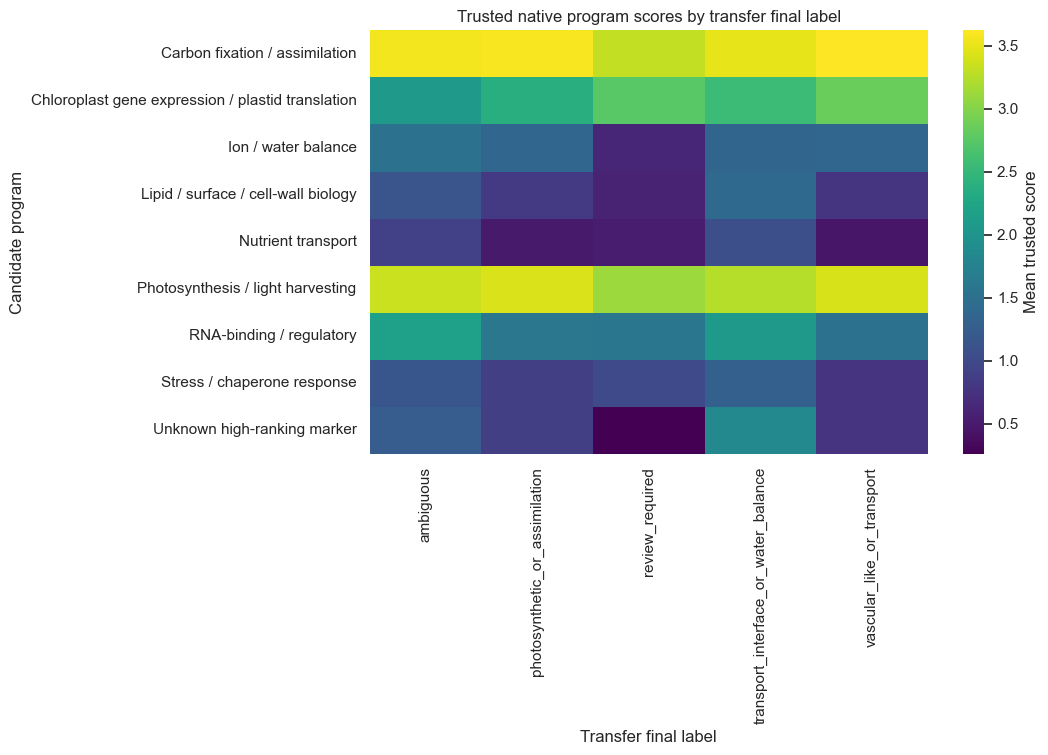

In [9]:
label_heatmap = (
    trusted_score_summary.query("grouping == 'final_label'")
    .pivot(index="native_program_name", columns="final_label", values="mean_score")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(label_heatmap, cmap="viridis", ax=ax, cbar_kws={"label": "Mean trusted score"})
ax.set_title("Trusted native program scores by transfer final label")
ax.set_xlabel("Transfer final label")
ax.set_ylabel("Candidate program")
fig_path = OUT_FIG / "trusted_native_program_scores_by_transfer_label.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
print("Wrote:", fig_path)
plt.show()

## Takeaways

The exact values below are generated from the executed notebook outputs.

In [10]:
def timepoint_delta(program_id):
    sub = trusted_score_summary.query("grouping == 'timepoint' and native_program_id == @program_id")
    vals = dict(zip(sub["timepoint"], sub["mean_score"]))
    return vals.get("dawn", np.nan), vals.get("dusk", np.nan), vals.get("dawn", np.nan) - vals.get("dusk", np.nan)

for pid in program_order:
    dawn, dusk, delta = timepoint_delta(pid)
    print(f"{program_name_lookup[pid]}: dawn={dawn:.4f}, dusk={dusk:.4f}, dawn-minus-dusk={delta:.4f}")

print(f"Total cells scored: {combined.n_obs:,}")
print(f"Trusted marker-program pairs: {len(trusted_panel):,}")

Carbon fixation / assimilation: dawn=3.6592, dusk=3.4655, dawn-minus-dusk=0.1937
Photosynthesis / light harvesting: dawn=3.7894, dusk=2.9205, dawn-minus-dusk=0.8689
Lipid / surface / cell-wall biology: dawn=1.0396, dusk=1.1679, dawn-minus-dusk=-0.1283
Stress / chaperone response: dawn=0.9416, dusk=1.3180, dawn-minus-dusk=-0.3764
Chloroplast gene expression / plastid translation: dawn=2.2797, dusk=1.9385, dawn-minus-dusk=0.3412
Ion / water balance: dawn=1.5674, dusk=1.4208, dawn-minus-dusk=0.1466
Nutrient transport: dawn=0.6674, dusk=1.0411, dawn-minus-dusk=-0.3737
Unknown high-ranking marker: dawn=1.2232, dusk=1.1875, dawn-minus-dusk=0.0357
RNA-binding / regulatory: dawn=1.2019, dusk=2.9863, dawn-minus-dusk=-1.7843
Total cells scored: 11,084
Trusted marker-program pairs: 60


## Interpretation notes

- Use the trusted panel as the practical baseline for future Wolffia data.
- Keep the broader candidate table for discovery and manual review.
- The unknown-marker watchlist is useful for Wolffia-specific biology, but it should not be interpreted as a named program until the genes are better annotated.
- For future control versus salt-stress data, score cells with this trusted panel and compare score shifts by sample, replicate, and cluster.